# Time Series Transformer for P(RUL > 2 days) Classification

**Task:** Binary classification. Predict whether Remaining Useful Life of an aircraft part exceeds 2 days, derived from `before_after` and `date_diff`.

**Model:** Transformer Encoder (PyTorch)

**Status:** Pipeline with full preprocessing inline (RUL labeling, channel drop, cruise filtering, RobustScaler). Replace the assumption block with the official feature engineering output when available.

---

## Pipeline Overview

1. Assumption block (preprocessing inline, sample 50 flights for testing)
2. Data Preparation (Dataset, DataLoader, attention masks)
3. Model Architecture (Transformer encoder)
4. Training Setup (loss, optimizer, scheduler, metrics)
5. Training Loop (composite score, checkpointing)
6. Evaluation (6 metrics, confusion matrix)
7. Ablation Studies (planning)
8. Documentation and Handoff


---
## Step 0. Assumption Block (Temporary)

**Purpose:** This block performs all necessary preprocessing inline to make the Transformer pipeline runnable without waiting for the official feature engineering output. Once the teammate's preprocessing file is ready, replace the **entire Step 0** with their data loader.

**Assumptions (all controlled here, sub steps below):**

1. **Sample size:** 50 flights (25 `before` + 25 `after`) for fast pipeline testing. Replace with full dataset later.
2. **Target labeling:** Binary `P(RUL > 2 days)` from paper.
   * Label 0 = `before_after == 'before'` AND `date_diff` in [-2, 0] → part will fail within 2 days
   * Label 1 = `before_after == 'after'` AND `date_diff` > 2 → part is healthy
3. **Train/val/test split:** **Time based** stratified split by `date_diff` to prevent temporal leakage.
4. **Channel selection:** Drop 7 redundant channels identified in EDA → keep 16 channels.
5. **Phase filtering:** Keep only cruise phase timesteps (IAS > 40 OR RPM > 1800) to address ground phase contamination.
6. **Sequence handling:** Pad/truncate to fixed `SEQ_LEN`. Owned by the Transformer pipeline.
7. **Scaling:** RobustScaler fit on **training data only** (no leakage), applied to val/test.


### 0.1 Imports and Configuration

In [8]:
import os
import numpy as np
import pandas as pd
import torch
import dask.dataframe as dd
from sklearn.preprocessing import RobustScaler

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ----- Sample configuration (THE ONLY THING TO TUNE FOR MOCK TEST) -----
N_PER_CLASS  = 25                # 25 before + 25 after = 50 flights total
SEQ_LEN      = 1000              # padded sequence length
N_CLASSES    = 2                 # binary: 0 = will fail, 1 = healthy

# ----- Labeling window (from paper) -----
RUL_WINDOW   = 2                 # 2 day window for P(RUL > 2 days)

# ----- Channels to keep (drop redundant ones identified in EDA) -----
ALL_CHANNELS = [
    'volt1', 'volt2', 'amp1', 'amp2', 'FQtyL', 'FQtyR',
    'E1 FFlow', 'E1 OilT', 'E1 OilP', 'E1 RPM',
    'E1 CHT1', 'E1 CHT2', 'E1 CHT3', 'E1 CHT4',
    'E1 EGT1', 'E1 EGT2', 'E1 EGT3', 'E1 EGT4',
    'OAT', 'IAS', 'VSpd', 'NormAc', 'AltMSL'
]
DROP_CHANNELS = ['volt2', 'amp2', 'E1 CHT2', 'E1 CHT3', 'E1 CHT4',
                 'E1 EGT2', 'E1 EGT3', 'E1 EGT4']
KEEP_CHANNELS = [c for c in ALL_CHANNELS if c not in DROP_CHANNELS]
N_CHANNELS = len(KEEP_CHANNELS)

print(f'Channels kept ({N_CHANNELS}): {KEEP_CHANNELS}')

# ----- Cruise phase filter thresholds -----
CRUISE_IAS_MIN = 40              # knots
CRUISE_RPM_MIN = 1800            # RPM

# ----- Data paths (matching EDA notebook) -----
DATA_DIR = '/kaggle/input/datasets/hooong/aviation-maintenance-dataset-from-the-ngafid/all_flights/all_flights'
HEADER_CSV   = os.path.join(DATA_DIR, 'flight_header.csv')
PARQUET_PATH = os.path.join(DATA_DIR, 'one_parq')


Channels kept (15): ['volt1', 'amp1', 'FQtyL', 'FQtyR', 'E1 FFlow', 'E1 OilT', 'E1 OilP', 'E1 RPM', 'E1 CHT1', 'E1 EGT1', 'OAT', 'IAS', 'VSpd', 'NormAc', 'AltMSL']


### 0.2 Build Target Variable + Sample Flights

**Purpose:** Read the flight header CSV, apply the P(RUL > 2 days) labeling rule (using `before_after` + `date_diff` window from the paper), then sample 25 flights from each class.


In [9]:
# Load full header
flight_header_df = pd.read_csv(HEADER_CSV, index_col='Master Index')
print(f'Total flights in header: {len(flight_header_df):,}')

# Apply P(RUL > 2 days) labeling rule from paper
will_fail = (
    (flight_header_df['before_after'] == 'before') &
    (flight_header_df['date_diff'].between(-RUL_WINDOW, 0))
)
healthy = (
    (flight_header_df['before_after'] == 'after') &
    (flight_header_df['date_diff'] > RUL_WINDOW)
)

# Also drop suspiciously short flights (under 100 timesteps)
length_ok = flight_header_df['flight_length'] >= 100

valid = flight_header_df[(will_fail | healthy) & length_ok].copy()
valid['y'] = healthy[valid.index].astype(int)  # 0 = will fail, 1 = healthy

print(f'After P(RUL>2) labeling and length filter: {len(valid):,}')
print(f'  Will fail (label 0): {(valid["y"] == 0).sum():,}')
print(f'  Healthy   (label 1): {(valid["y"] == 1).sum():,}')

# Sample N_PER_CLASS flights from each class
rng = np.random.default_rng(SEED)
sampled_ids = []
for cls in [0, 1]:
    pool = valid.index[valid['y'] == cls].to_numpy()
    picked = rng.choice(pool, size=min(N_PER_CLASS, len(pool)), replace=False)
    sampled_ids.extend(picked)
sampled_ids = np.array(sorted(sampled_ids))

sampled_header = valid.loc[sampled_ids].copy()
print(f'\nSampled {len(sampled_ids)} flights ({N_PER_CLASS} per class):')
print(sampled_header['y'].value_counts().rename({0: 'will_fail', 1: 'healthy'}))


Total flights in header: 28,935
After P(RUL>2) labeling and length filter: 10,159
  Will fail (label 0): 7,889
  Healthy   (label 1): 2,270

Sampled 50 flights (25 per class):
y
healthy      25
will_fail    25
Name: count, dtype: int64


### 0.3 Time Based Train / Val / Test Split

**Purpose:** Split the 50 flights into train/val/test using a **time based stratified split** on `date_diff` to prevent temporal leakage. Earliest flights go to train, latest go to test, simulating real world deployment where we predict on future flights using past data.


In [10]:
# Sort flights by date_diff (earlier = more negative, later = more positive)
# Within each class, take earliest 60% for train, next 20% for val, last 20% for test
sampled_header['rank_in_class'] = sampled_header.groupby('y')['date_diff'].rank(method='first')
sampled_header['frac_in_class'] = sampled_header['rank_in_class'] / sampled_header.groupby('y')['rank_in_class'].transform('max')

def assign_split(frac):
    if frac <= 0.60:
        return 'train'
    elif frac <= 0.80:
        return 'val'
    else:
        return 'test'

sampled_header['split'] = sampled_header['frac_in_class'].apply(assign_split)

# Get index lists for each split
idx_train_ids = sampled_header.index[sampled_header['split'] == 'train'].to_numpy()
idx_val_ids   = sampled_header.index[sampled_header['split'] == 'val'].to_numpy()
idx_test_ids  = sampled_header.index[sampled_header['split'] == 'test'].to_numpy()

print(f'Train: {len(idx_train_ids):,} flights | y dist: {sampled_header.loc[idx_train_ids, "y"].value_counts().to_dict()}')
print(f'Val  : {len(idx_val_ids):,} flights | y dist: {sampled_header.loc[idx_val_ids, "y"].value_counts().to_dict()}')
print(f'Test : {len(idx_test_ids):,} flights | y dist: {sampled_header.loc[idx_test_ids, "y"].value_counts().to_dict()}')

print(f'\nDate_diff ranges (no overlap = no leakage):')
for split in ['train', 'val', 'test']:
    sub = sampled_header[sampled_header['split'] == split]
    print(f'  {split:5s}: date_diff in [{sub["date_diff"].min():.0f}, {sub["date_diff"].max():.0f}]')


Train: 30 flights | y dist: {1: 15, 0: 15}
Val  : 10 flights | y dist: {1: 5, 0: 5}
Test : 10 flights | y dist: {1: 5, 0: 5}

Date_diff ranges (no overlap = no leakage):
  train: date_diff in [-2, 4]
  val  : date_diff in [-1, 5]
  test : date_diff in [-1, 10]


### 0.4 Load Sensor Data via Dask

**Purpose:** Read the parquet sensor data lazily and filter to only the 50 sampled flights in one scan.


In [11]:
# Lazy load full parquet
flight_data_df = dd.read_parquet(PARQUET_PATH)
print(f'Parquet partitions: {flight_data_df.npartitions}')

# Filter inside each partition to only sampled IDs
sampled_set = set(sampled_ids)
def keep_sampled(df):
    return df[df.index.isin(sampled_set)]

print('\nLoading 50 flights from parquet (this may take 1-2 minutes)...')
sampled_pd = flight_data_df.map_partitions(keep_sampled).compute()
print(f'Loaded {len(sampled_pd):,} rows for {sampled_pd.index.nunique()} flights')


Parquet partitions: 401

Loading 50 flights from parquet (this may take 1-2 minutes)...
Loaded 261,650 rows for 50 flights


### 0.5 Cruise Phase Filtering + Channel Selection

**Purpose:** Address the bimodality issue identified in EDA (engine off / ground phase contamination). Keep only timesteps in **cruise phase** (IAS > 40 OR RPM > 1800), then drop the 7 redundant channels.


In [12]:
# Apply cruise phase filter
def filter_cruise(df):
    """Keep only cruise phase timesteps."""
    if 'IAS' not in df.columns or 'E1 RPM' not in df.columns:
        return df  # safety fallback
    cruise_mask = (df['IAS'].fillna(0) > CRUISE_IAS_MIN) | (df['E1 RPM'].fillna(0) > CRUISE_RPM_MIN)
    return df[cruise_mask]

print('Filtering cruise phase only...')
cruise_pd = sampled_pd.groupby(level=0, group_keys=False).apply(filter_cruise)
print(f'Before cruise filter: {len(sampled_pd):,} rows')
print(f'After cruise filter : {len(cruise_pd):,} rows ({len(cruise_pd)/len(sampled_pd)*100:.1f}% kept)')

# Select kept channels
cruise_pd = cruise_pd[KEEP_CHANNELS]
print(f'Channels selected: {cruise_pd.shape[1]}')

# Drop any flight that has no cruise-phase data
flights_with_data = cruise_pd.index.unique()
removed_flights = set(sampled_ids) - set(flights_with_data)
if removed_flights:
    print(f'Warning: {len(removed_flights)} flights had no cruise data and were removed.')
    sampled_ids = np.array([fid for fid in sampled_ids if fid in flights_with_data])
    idx_train_ids = np.array([fid for fid in idx_train_ids if fid in flights_with_data])
    idx_val_ids   = np.array([fid for fid in idx_val_ids   if fid in flights_with_data])
    idx_test_ids  = np.array([fid for fid in idx_test_ids  if fid in flights_with_data])


Filtering cruise phase only...
Before cruise filter: 261,650 rows
After cruise filter : 200,210 rows (76.5% kept)
Channels selected: 15


### 0.6 Build Tensors with Padding + Attention Mask

**Purpose:** Convert per flight DataFrames into a fixed shape tensor `(n_flights, SEQ_LEN, n_channels)`. Pad with zeros (right side) if shorter than SEQ_LEN, truncate if longer. Build an attention mask marking real vs. padded positions.

This step is owned by the Transformer pipeline (not feature engineering) because padding/truncation is model-specific.


In [13]:
N_TOTAL = len(sampled_ids)

X = np.zeros((N_TOTAL, SEQ_LEN, N_CHANNELS), dtype=np.float32)
mask = np.zeros((N_TOTAL, SEQ_LEN), dtype=np.float32)
y = np.zeros(N_TOTAL, dtype=np.int64)
master_indices = np.zeros(N_TOTAL, dtype=np.int64)

for i, flight_id in enumerate(sampled_ids):
    flight_df = cruise_pd.loc[[flight_id]] if isinstance(cruise_pd.loc[flight_id], pd.Series) else cruise_pd.loc[flight_id]
    if isinstance(flight_df, pd.Series):
        flight_df = flight_df.to_frame().T

    arr = flight_df[KEEP_CHANNELS].to_numpy(dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0)

    # Truncate or pad
    L = min(arr.shape[0], SEQ_LEN)
    X[i, :L] = arr[:L]
    mask[i, :L] = 1.0

    y[i] = sampled_header.loc[flight_id, 'y']
    master_indices[i] = flight_id

# Rebuild index lookups in the order of the X array
id_to_pos = {fid: i for i, fid in enumerate(master_indices)}
idx_train = np.array([id_to_pos[f] for f in idx_train_ids])
idx_val   = np.array([id_to_pos[f] for f in idx_val_ids])
idx_test  = np.array([id_to_pos[f] for f in idx_test_ids])

print(f'X shape : {X.shape}')
print(f'mask shape : {mask.shape}')
print(f'y shape : {y.shape}  distribution: {np.bincount(y)}')
print(f'\nReal length stats (cruise-phase): min={mask.sum(axis=1).min():.0f}, '
      f'mean={mask.sum(axis=1).mean():.0f}, max={mask.sum(axis=1).max():.0f}')
print(f'\nSplit sizes: train={len(idx_train)}, val={len(idx_val)}, test={len(idx_test)}')


X shape : (48, 1000, 15)
mask shape : (48, 1000)
y shape : (48,)  distribution: [24 24]

Real length stats (cruise-phase): min=21, mean=927, max=1000

Split sizes: train=29, val=10, test=9


### 0.7 Per Channel Scaling (Fit on Train Only)

**Purpose:** Apply RobustScaler to each channel. Fit only on **training data** (real cruise timesteps), then apply to val/test. This prevents data leakage where test data influences the scaler.


In [14]:
# Extract training cruise data only (no padding, no val, no test)
train_real_data = X[idx_train][mask[idx_train].astype(bool)]  # (n_train_real_steps, n_channels)
print(f'Training real cruise timesteps: {train_real_data.shape}')

# Fit scaler on training data only
scaler = RobustScaler()
scaler.fit(train_real_data)
print(f'Scaler fit on train only.')
print(f'  Channel medians (first 5): {scaler.center_[:5].round(3)}')
print(f'  Channel IQRs    (first 5): {scaler.scale_[:5].round(3)}')

# Apply to all data (train + val + test)
X_flat = X.reshape(-1, N_CHANNELS)
X_scaled = scaler.transform(X_flat).reshape(X.shape).astype(np.float32)

# Re zero padded positions
X_scaled = X_scaled * mask[..., np.newaxis]

print(f'\nFinal tensors ready for downstream:')
print(f'  X_scaled       : {X_scaled.shape}')
print(f'  mask           : {mask.shape}')
print(f'  y              : {y.shape}')
print(f'  idx_train/val/test sizes: {len(idx_train)}/{len(idx_val)}/{len(idx_test)}')

# Names matching downstream pipeline (do not change these)
X_mock = X_scaled
mask_mock = mask
y_mock = y


Training real cruise timesteps: (27591, 15)
Scaler fit on train only.
  Channel medians (first 5): [28.1   1.1  20.31 21.84  8.65]
  Channel IQRs    (first 5): [0.1  1.2  3.79 2.89 4.61]

Final tensors ready for downstream:
  X_scaled       : (48, 1000, 15)
  mask           : (48, 1000)
  y              : (48,)
  idx_train/val/test sizes: 29/10/9


---
## Step 1. Data Preparation

### 1.1 PyTorch Dataset and DataLoader

**Purpose:** Wrap the preprocessed arrays into a PyTorch `Dataset` so we can iterate in batches. Each sample returns the sensor tensor, the attention mask, and the label. The train/val/test splits were already determined in Step 0.3.


In [15]:
from torch.utils.data import Dataset, DataLoader

class FlightDataset(Dataset):
    """Wraps preprocessed flight tensors for the Transformer."""

    def __init__(self, X, mask, y):
        self.X    = torch.from_numpy(X).float()
        self.mask = torch.from_numpy(mask).float()
        self.y    = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.mask[i], self.y[i]


BATCH_SIZE = 4

train_ds = FlightDataset(X_mock[idx_train], mask_mock[idx_train], y_mock[idx_train])
val_ds   = FlightDataset(X_mock[idx_val],   mask_mock[idx_val],   y_mock[idx_val])
test_ds  = FlightDataset(X_mock[idx_test],  mask_mock[idx_test],  y_mock[idx_test])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# Sanity check
xb, mb, yb = next(iter(train_loader))
print(f'Batch X    : {xb.shape}')
print(f'Batch mask : {mb.shape}')
print(f'Batch y    : {yb.shape}  values={yb.tolist()}')


Batch X    : torch.Size([4, 1000, 15])
Batch mask : torch.Size([4, 1000])
Batch y    : torch.Size([4])  values=[1, 1, 0, 0]


---
## Step 2. Model Architecture

### 2.1 Positional Encoding

**Purpose:** Transformers have no built in notion of sequence order. We add a sinusoidal positional encoding so the model knows which timestep is which. Sinusoidal is parameter free and generalizes to sequence lengths unseen during training.


In [16]:
import math
import torch.nn as nn

class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding from Vaswani et al. (2017)."""

    def __init__(self, d_model, max_len=10000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


### 2.2 Transformer Classifier

**Purpose:** Defines the full model. The pipeline projects sensor channels into a `d_model` dimensional embedding, adds positional encoding, passes through Transformer encoder layers, applies masked mean pooling, then a linear layer produces 2 class logits.


In [17]:
class FlightTransformer(nn.Module):
    def __init__(self, n_channels, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.1, n_classes=2, max_len=10000):
        super().__init__()
        self.input_proj = nn.Linear(n_channels, d_model)
        self.pos_enc    = PositionalEncoding(d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward, dropout=dropout,
            batch_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(d_model, n_classes)

    def forward(self, x, mask):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        key_padding_mask = (mask == 0)
        x = self.encoder(x, src_key_padding_mask=key_padding_mask)
        x = self.norm(x)

        # Masked mean pooling
        mask_exp = mask.unsqueeze(-1)
        x_sum    = (x * mask_exp).sum(dim=1)
        x_mean   = x_sum / mask_exp.sum(dim=1).clamp(min=1e-6)

        x_mean = self.dropout(x_mean)
        return self.head(x_mean)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FlightTransformer(
    n_channels=N_CHANNELS, d_model=64, nhead=4, num_layers=2,
    dim_feedforward=128, dropout=0.1, n_classes=N_CLASSES, max_len=SEQ_LEN
).to(device)

print(model)
print(f'\nTotal params: {sum(p.numel() for p in model.parameters()):,}')
print(f'Device      : {device}')


FlightTransformer(
  (input_proj): Linear(in_features=15, out_features=64, bias=True)
  (pos_enc): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (head): Linear(in_features=64, out_features=2, bias=True)
)

Total params

---
## Step 3. Training Setup

**Purpose:** Define the loss function, optimizer, learning rate scheduler. Cross entropy with class weights handles imbalance. AdamW with OneCycleLR is the standard recipe for Transformers.


In [18]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

# Class weights computed from training labels
class_counts = np.bincount(y_mock[idx_train], minlength=N_CLASSES)
class_weights = torch.tensor(
    len(idx_train) / (N_CLASSES * np.maximum(class_counts, 1)),
    dtype=torch.float32, device=device
)
print(f'Class counts (train): {class_counts}')
print(f'Class weights        : {class_weights.cpu().numpy()}')

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

N_EPOCHS  = 5
scheduler = OneCycleLR(
    optimizer, max_lr=1e-3,
    steps_per_epoch=len(train_loader), epochs=N_EPOCHS,
    pct_start=0.1, anneal_strategy='cos'
)


Class counts (train): [15 14]
Class weights        : [0.96666664 1.0357143 ]


### 3.1 Evaluation Metrics

**Purpose:** Compute all 6 metrics from the project's evaluation criteria: Recall, Precision, F1, ROC-AUC, PR-AUC, Confusion Matrix, plus inference time.


In [19]:
import time
import torch.nn.functional as F
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score,
                              roc_auc_score, average_precision_score, confusion_matrix)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    start_time = time.time()
    total_samples = 0

    for xb, mb, yb in loader:
        xb, mb, yb = xb.to(device), mb.to(device), yb.to(device)
        logits = model(xb, mb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        probs = F.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        total_samples += xb.size(0)

    elapsed = time.time() - start_time
    inference_ms = elapsed / total_samples * 1000

    avg_loss  = total_loss / len(loader.dataset)
    acc       = accuracy_score(all_labels, all_preds)
    recall_per_class    = recall_score(all_labels, all_preds, average=None, zero_division=0)
    recall_macro        = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    precision_per_class = precision_score(all_labels, all_preds, average=None, zero_division=0)
    precision_macro     = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_macro            = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    try:
        roc_auc = roc_auc_score(all_labels, all_probs)
        pr_auc  = average_precision_score(all_labels, all_probs)
    except ValueError:
        roc_auc = pr_auc = float('nan')
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(N_CLASSES)))

    return {
        'loss': avg_loss, 'accuracy': acc,
        'recall_macro': recall_macro, 'recall_per_class': recall_per_class,
        'precision_macro': precision_macro, 'precision_per_class': precision_per_class,
        'f1_macro': f1_macro, 'roc_auc': roc_auc, 'pr_auc': pr_auc,
        'confusion_matrix': cm, 'inference_ms_per_flight': inference_ms,
        'preds': all_preds, 'labels': all_labels, 'probs': all_probs,
    }


---
## Step 4. Training Loop with Composite Best-Model Selection

**Purpose:** Iterate over epochs and save the best checkpoint using a **composite score** that weighs Recall on the failure class (safety) and F1-macro (balance). This reflects the aviation safety priority where missing a failure is worse than a false alarm.


In [20]:
import copy

# Reset scheduler (allows re-running this cell safely)
scheduler = OneCycleLR(
    optimizer, max_lr=1e-3,
    steps_per_epoch=len(train_loader), epochs=N_EPOCHS,
    pct_start=0.1, anneal_strategy='cos'
)

# Composite weights: prioritize catching failures
W_RECALL_FAIL = 0.7   # safety
W_F1_MACRO    = 0.3   # balance

history = {'train_loss': [], 'val_loss': [], 'val_f1': [],
           'val_recall_fail': [], 'val_composite': []}
best_composite, best_state = -1.0, None

for epoch in range(1, N_EPOCHS + 1):
    # Train
    model.train()
    epoch_loss = 0.0
    for xb, mb, yb in train_loader:
        xb, mb, yb = xb.to(device), mb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb, mb)
        loss   = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item() * xb.size(0)
    train_loss = epoch_loss / len(train_loader.dataset)

    # Validate
    val = evaluate(model, val_loader, criterion)
    val_recall_fail = val['recall_per_class'][0]
    composite = W_RECALL_FAIL * val_recall_fail + W_F1_MACRO * val['f1_macro']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val['loss'])
    history['val_f1'].append(val['f1_macro'])
    history['val_recall_fail'].append(val_recall_fail)
    history['val_composite'].append(composite)

    if composite > best_composite:
        best_composite = composite
        best_state = copy.deepcopy(model.state_dict())
        flag = '  <-- best'
    else:
        flag = ''

    print(f'Epoch {epoch:2d}/{N_EPOCHS} | train_loss={train_loss:.4f} | '
          f'val_loss={val["loss"]:.4f} | F1={val["f1_macro"]:.4f} | '
          f'RecallFail={val_recall_fail:.4f} | Composite={composite:.4f}{flag}')

if best_state is not None:
    model.load_state_dict(best_state)
print(f'\nBest composite score: {best_composite:.4f}')
print(f'Composite = {W_RECALL_FAIL} * Recall(fail) + {W_F1_MACRO} * F1-macro')


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch  1/5 | train_loss=0.7996 | val_loss=0.7609 | F1=0.3333 | RecallFail=0.0000 | Composite=0.1000  <-- best
Epoch  2/5 | train_loss=0.7636 | val_loss=0.7062 | F1=0.4505 | RecallFail=0.2000 | Composite=0.2752  <-- best
Epoch  3/5 | train_loss=0.6108 | val_loss=0.6920 | F1=0.6970 | RecallFail=0.8000 | Composite=0.7691  <-- best
Epoch  4/5 | train_loss=0.5602 | val_loss=0.6847 | F1=0.6970 | RecallFail=0.6000 | Composite=0.6291
Epoch  5/5 | train_loss=0.5320 | val_loss=0.6858 | F1=0.5833 | RecallFail=0.4000 | Composite=0.4550

Best composite score: 0.7691
Composite = 0.7 * Recall(fail) + 0.3 * F1-macro


---
## Step 5. Evaluation and Analysis

### 5.1 Test Set Metrics

**Purpose:** Apply the best checkpoint to the held out test set and report all 6 metrics from the project's evaluation criteria, plus inference time.


In [21]:
test_result = evaluate(model, test_loader, criterion)

print('=' * 60)
print('TEST SET METRICS')
print('=' * 60)
print(f'Loss             : {test_result["loss"]:.4f}')
print(f'Accuracy         : {test_result["accuracy"]:.4f}')
print()
print('--- Safety-critical metrics ---')
print(f'Recall (macro)   : {test_result["recall_macro"]:.4f}')
print(f'  Class 0 (will fail): {test_result["recall_per_class"][0]:.4f}  (catches failures)')
print(f'  Class 1 (healthy)  : {test_result["recall_per_class"][1]:.4f}')
print()
print('--- Operational cost metrics ---')
print(f'Precision (macro): {test_result["precision_macro"]:.4f}')
print(f'  Class 0 (will fail): {test_result["precision_per_class"][0]:.4f}  (avoids false alarms)')
print(f'  Class 1 (healthy)  : {test_result["precision_per_class"][1]:.4f}')
print()
print('--- Balanced metric ---')
print(f'F1-macro         : {test_result["f1_macro"]:.4f}')
print()
print('--- Threshold-independent metrics ---')
print(f'ROC-AUC          : {test_result["roc_auc"]:.4f}')
print(f'PR-AUC           : {test_result["pr_auc"]:.4f}')
print()
print('--- Operational metric ---')
print(f'Inference time   : {test_result["inference_ms_per_flight"]:.2f} ms per flight')
print()
print('--- Confusion Matrix ---')
print('              Pred=0(fail)  Pred=1(healthy)')
print(f'True=0(fail)    {test_result["confusion_matrix"][0,0]:>6d}        {test_result["confusion_matrix"][0,1]:>6d}')
print(f'True=1(healthy) {test_result["confusion_matrix"][1,0]:>6d}        {test_result["confusion_matrix"][1,1]:>6d}')
print()
print('Interpretation:')
print('  TP (top-left): correctly flagged faulty parts (good for safety)')
print('  FN (top-right): missed failures (SAFETY-CRITICAL miss)')
print('  FP (bottom-left): false alarms (unnecessary maintenance cost)')
print('  TN (bottom-right): correctly cleared healthy (good for operations)')


TEST SET METRICS
Loss             : 0.9491
Accuracy         : 0.1111

--- Safety-critical metrics ---
Recall (macro)   : 0.1250
  Class 0 (will fail): 0.2500  (catches failures)
  Class 1 (healthy)  : 0.0000

--- Operational cost metrics ---
Precision (macro): 0.0833
  Class 0 (will fail): 0.1667  (avoids false alarms)
  Class 1 (healthy)  : 0.0000

--- Balanced metric ---
F1-macro         : 0.1000

--- Threshold-independent metrics ---
ROC-AUC          : 0.0000
PR-AUC           : 0.4035

--- Operational metric ---
Inference time   : 1.84 ms per flight

--- Confusion Matrix ---
              Pred=0(fail)  Pred=1(healthy)
True=0(fail)         1             3
True=1(healthy)      5             0

Interpretation:
  TP (top-left): correctly flagged faulty parts (good for safety)
  FN (top-right): missed failures (SAFETY-CRITICAL miss)
  FP (bottom-left): false alarms (unnecessary maintenance cost)
  TN (bottom-right): correctly cleared healthy (good for operations)


### 5.2 Training Curves

**Purpose:** Visualize training and validation loss, F1, and composite score across epochs.


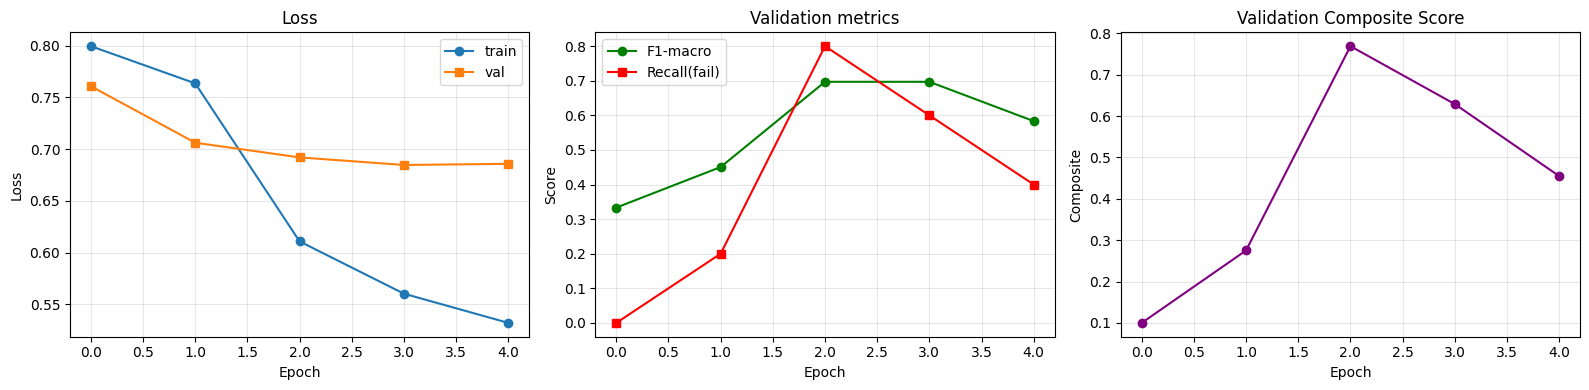

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['train_loss'], label='train', marker='o')
axes[0].plot(history['val_loss'],   label='val',   marker='s')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['val_f1'], color='green', marker='o', label='F1-macro')
axes[1].plot(history['val_recall_fail'], color='red', marker='s', label='Recall(fail)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score'); axes[1].set_title('Validation metrics')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history['val_composite'], color='purple', marker='o')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Composite'); axes[2].set_title('Validation Composite Score')
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()


### 5.3 Attention Visualization (optional)

**Purpose:** Extract attention weights from the first encoder layer to see which timesteps the model attends to. Implement after real-data training.


In [23]:
print('Attention visualization. Implement after real-data training.')

Attention visualization. Implement after real-data training.


---
## Step 6. Ablation Studies (planning)

**Purpose:** Once the real data baseline is established, run controlled experiments to understand which design choices matter.

Planned ablations:

1. **Positional encoding:** sinusoidal vs. learned vs. none
2. **Pooling strategy:** masked mean vs. CLS token vs. attention pooling
3. **Channel reduction:** full 23 vs. reduced 16
4. **Sequence length:** truncate at p75 vs. p90 vs. p95
5. **Downsampling:** every 1s vs. every 5s vs. every 10s
6. **Phase filtering:** cruise only vs. airborne vs. full flight


---
## Step 7. Documentation and Handoff


In [24]:
import json
from pathlib import Path

OUT_DIR = Path('./transformer_artifacts')
OUT_DIR.mkdir(exist_ok=True)

torch.save(model.state_dict(), OUT_DIR / 'best_model.pt')

config = {
    'n_channels'     : N_CHANNELS,
    'kept_channels'  : KEEP_CHANNELS,
    'seq_len'        : SEQ_LEN,
    'n_classes'      : N_CLASSES,
    'rul_window_days': RUL_WINDOW,
    'cruise_ias_min' : CRUISE_IAS_MIN,
    'cruise_rpm_min' : CRUISE_RPM_MIN,
    'd_model'        : 64,
    'nhead'          : 4,
    'num_layers'     : 2,
    'dim_feedforward': 128,
    'dropout'        : 0.1,
    'batch_size'     : BATCH_SIZE,
    'n_epochs'       : N_EPOCHS,
    'composite_weights': {'recall_fail': W_RECALL_FAIL, 'f1_macro': W_F1_MACRO},
    'best_val_composite': float(best_composite),
    'test_f1'        : float(test_result['f1_macro']),
    'test_recall_fail': float(test_result['recall_per_class'][0]),
    'test_roc_auc'   : float(test_result['roc_auc']) if not np.isnan(test_result['roc_auc']) else None,
    'test_pr_auc'    : float(test_result['pr_auc']) if not np.isnan(test_result['pr_auc']) else None,
    'inference_ms_per_flight': float(test_result['inference_ms_per_flight']),
    'sampled_master_indices': master_indices.tolist(),
}
with open(OUT_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f'Saved to {OUT_DIR.resolve()}/')
print(json.dumps(config, indent=2))


Saved to /kaggle/working/transformer_artifacts/
{
  "n_channels": 15,
  "kept_channels": [
    "volt1",
    "amp1",
    "FQtyL",
    "FQtyR",
    "E1 FFlow",
    "E1 OilT",
    "E1 OilP",
    "E1 RPM",
    "E1 CHT1",
    "E1 EGT1",
    "OAT",
    "IAS",
    "VSpd",
    "NormAc",
    "AltMSL"
  ],
  "seq_len": 1000,
  "n_classes": 2,
  "rul_window_days": 2,
  "cruise_ias_min": 40,
  "cruise_rpm_min": 1800,
  "d_model": 64,
  "nhead": 4,
  "num_layers": 2,
  "dim_feedforward": 128,
  "dropout": 0.1,
  "batch_size": 4,
  "n_epochs": 5,
  "composite_weights": {
    "recall_fail": 0.7,
    "f1_macro": 0.3
  },
  "best_val_composite": 0.769090909090909,
  "test_f1": 0.1,
  "test_recall_fail": 0.25,
  "test_roc_auc": 0.0,
  "test_pr_auc": 0.40349206349206346,
  "inference_ms_per_flight": 1.8393728468153212,
  "sampled_master_indices": [
    1397,
    2603,
    3263,
    3367,
    3503,
    4655,
    4731,
    5369,
    6682,
    6749,
    7255,
    10950,
    12129,
    12193,
    12306,
    

---
## Compatibility Checklist for Feature Engineering Handoff

When the feature engineering teammate delivers their preprocessing file, verify it produces these outputs:

| Variable | Type | Shape | Description |
|----------|------|-------|-------------|
| `X_mock` | np.float32 | (n_flights, SEQ_LEN, n_channels) | Padded, scaled sensor tensor |
| `mask_mock` | np.float32 | (n_flights, SEQ_LEN) | 1 = real, 0 = padded |
| `y_mock` | np.int64 | (n_flights,) | 0 = will fail, 1 = healthy |
| `idx_train` | np.array | indices into X_mock | Train split |
| `idx_val` | np.array | indices into X_mock | Validation split |
| `idx_test` | np.array | indices into X_mock | Test split |

Their pipeline should perform:

1. P(RUL > 2 days) labeling using `before_after` + `date_diff`
2. Cruise phase filtering (or equivalent)
3. Channel selection (drop redundant)
4. Time based stratified split
5. RobustScaler fit on train only
6. Padding/truncation to fixed SEQ_LEN

If all 6 boxes are checked, **delete the entire Step 0** and replace with one cell that loads their saved tensors.
